In [1]:
from pathlib import Path

CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")
WANDB_TAG = "Run_2703"  # wandb tag to select runs (set as needed)

arial_path = "/global/homes/g/gregork/.local/share/fonts/ARIAL.TTF"

# Eval Regression – q3 vs IQR/RMS, residuals by energy, IQR vs training samples (bin 2)
# Plots saved as PDFs in out/regression_eval
import matplotlib
from matplotlib import font_manager

# Point directly to one of the Arial TTF files we just unpacked
# Register this font with Matplotlib
font_manager.fontManager.addfont(arial_path)
matplotlib.rcParams["font.family"] = ["Arial", "sans-serif"]

import sys
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
if str(ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(ROOT / "notebooks"))

OUT_DIR = ROOT / "out" / "regression_eval_1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUPPRESS_ERRORS = True

In [2]:
# Build model -> runs for full dataset (cap=-1) and for scaling (all caps)
from src.utils.utils import get_runs_by_model_and_cap

runs_by_model_cap = get_runs_by_model_and_cap(WANDB_TAG)

# Full-dataset runs: one run per model (cap=-1)
training_names_full = {"Log1p": {}}
baseline_run = None
for model, caps in runs_by_model_cap.items():
    if -1 in caps.keys():
        run = caps[-1]
        training_names_full["Log1p"][model] = run
        if baseline_run is None:
            baseline_run = run[-1]

if not training_names_full["Log1p"]:
    raise SystemExit("No runs with cap=-1 found. Check WANDB_TAG and wandb.")
if baseline_run is None:
    baseline_run = list(training_names_full["Log1p"].values())[0]
print("Full-dataset models:", list(training_names_full["Log1p"].keys()))
print("Baseline run for filters/baselines:", baseline_run)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /global/homes/g/gregork/.netrc.


Calling wandb API...


  Fetching runs from fcc_ml/minerva-models with tag 'Run_2703'...


  Wandb API finished: 71 run(s) found with tag 'Run_2703'.
Full-dataset models: ['MLP', 'Transformer-xsmall', 'Transformer-small', 'OmniLearned-medium', 'OmniLearned-small-rw', 'OmniLearned-small']
Baseline run for filters/baselines: Run_cond_only_lowLR_NR_full_seed50_20260404_100445


In [3]:
# print dict of runs
print(training_names_full)
print({key: len(value) for key, value in training_names_full["Log1p"].items()})

{'Log1p': {'MLP': ['Run_cond_only_lowLR_NR_full_seed52_20260405_021314', 'Run_cond_only_lowLR_NR_full_seed51_20260404_194045', 'Run_cond_only_lowLR_NR_full_seed53_20260405_085001', 'Run_cond_only_lowLR_NR_full_seed50_20260404_100445'], 'Transformer-xsmall': ['Run_1703_regression_Transformer1NR_data_cap_-1_seed_52_20260330_234121', 'Run_1703_regression_Transformer1NR_data_cap_-1_seed_53_20260330_235127', 'Run_1703_regression_Transformer1NR_data_cap_-1_seed_46_20260326_143107', 'Run_1703_regression_Transformer1NR_data_cap_-1_seed_51_20260329_014843', 'Run_1703_regression_Transformer1NR_data_cap_-1_seed_50_20260328_155006', 'Run_1703_regression_Transformer1NR_data_cap_-1_seed_46_20260327_020222'], 'Transformer-small': ['Run_1703_regression_Transformer3NR_data_cap_-1_seed_50_20260328_155130', 'Run_1703_regression_Transformer3NR_data_cap_-1_seed_52_20260330_234305', 'Run_1703_regression_Transformer3NR_data_cap_-1_seed_51_20260329_014844', 'Run_1703_regression_Transformer3NR_data_cap_-1_seed

## (I) q3 vs IQR and RMS – full training dataset

Skipping Run_1703_OLM_FB_regression_-1_seed52_20260406_130801 on playlist 1A (no eval results found)


Skipping Run_1703_OLM_FB_regression_-1_seed53_20260406_132149 on playlist 1A (no eval results found)


keys:  dict_keys(['1A', '1B'])


  baseline: RMS = [2.8419746872321565, 2.2176398351942384, 1.758116717480389, 1.504561280576312, 1.4609254305037722], IQR = [1.1480749775136398, 0.7115179810480453, 0.5896458729592533, 0.5301364134724922, 0.4837199325457493], MPV = [1.1400000000000001, 0.9, 0.86, 0.86, 0.86]
E_pred_dict keys for '1A': {'Log1p': ['MLP§0', 'MLP§1', 'MLP§2', 'MLP§3', 'Transformer-xsmall§0', 'Transformer-xsmall§1', 'Transformer-xsmall§2', 'Transformer-xsmall§3', 'Transformer-xsmall§4', 'Transformer-xsmall§5', 'Transformer-small§0', 'Transformer-small§1', 'Transformer-small§2', 'Transformer-small§3', 'OmniLearned-medium§0', 'OmniLearned-medium§2', 'OmniLearned-small§0', 'OmniLearned-small§1', 'OmniLearned-small§2', 'OmniLearned-small§3']}
  MLP (Log1p):
    RMS = [2.484382450580597, 1.6729150712490082, 1.2688360810279846, 1.1612243056297302, 1.0977802276611328]
    IQR = [0.9593096077442169, 0.6122481822967529, 0.5027910321950912, 0.45515887439250946, 0.4173704981803894]
    MPV = [1.100000023841858, 1.0, 0

  Transformer-xsmall (Log1p):
    RMS = [2.0891559521357217, 1.4580405155817668, 1.134791413942973, 1.1055286129315693, 1.0664284427960713]
    IQR = [0.7727286517620087, 0.5490889052549998, 0.46021680037180585, 0.4218603273232778, 0.3932352264722188]
    MPV = [0.9599999984105428, 0.9633333285649618, 0.9333333273728689, 0.8966666460037231, 0.8966666559378306]
  Transformer-small (Log1p):
    RMS = [2.084521621465683, 1.4700565040111542, 1.1303295493125916, 1.106362909078598, 1.0533323287963867]
    IQR = [0.7920163869857788, 0.5543249547481537, 0.4630279392004013, 0.42227810621261597, 0.39526280760765076]
    MPV = [0.929999977350235, 0.9600000083446503, 0.9399999976158142, 0.885000005364418, 0.8799999952316284]
  OmniLearned-medium (Log1p):
    RMS = [1.538932979106903, 1.7951734542846678, 1.0217846110463142, 1.9062727749347688, 0.9740488827228546]
    IQR = [0.8726597726345062, 0.7643675357103348, 0.7046999633312225, 0.6556449010968208, 0.6390745937824249]
    MPV = [0.4849999994039

  OmniLearned-small (Log1p):
    RMS = [1.9541826844215393, 1.4133227467536926, 1.1179623007774353, 1.1017500758171082, 1.0508244633674622]
    IQR = [0.7055612951517105, 0.5118752866983414, 0.4471462666988373, 0.4164040982723236, 0.3928162157535553]
    MPV = [0.9749999940395355, 0.939999982714653, 0.9199999868869781, 0.9249999970197678, 0.9099999815225601]


Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval_1/q3_vs_iqr_rms_full_1A.pdf


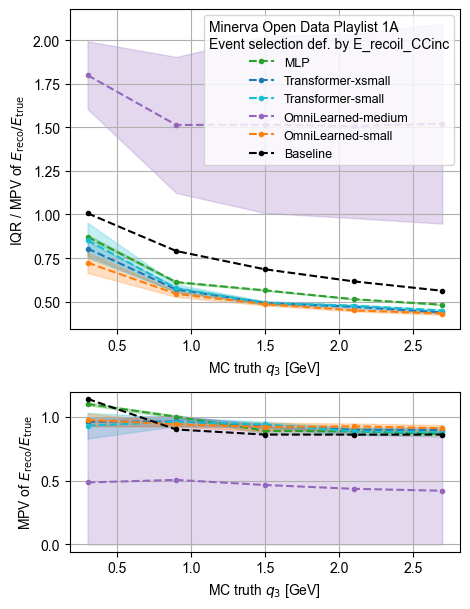

In [4]:
from eval_E_available_plots import plot_rms_iqr, plot_rms_iqr_with_uncertainty

clrs_dict_full = {
    "Transformer-xsmall": "#1f77b4",     # a nice blue
    "Transformer-small": "#17becf",     # cyan (same ViT depth as T1; no E_recoil cond)
    "OmniLearned-small": "#ff7f0e",     # a vibrant orange
    "MLP": "#2ca02c",                   # a pleasant green
    "OmniLearned-medium": "#9467bd",    # a pretty purple
    "OmniLearned-small-rw": "#c7c7c7",  # a distinct pink/magenta, distant from others
}

training_names_full_no_rw = {
    "Log1p": {}
} # remove -rw models from triannig_names_full

for key in training_names_full["Log1p"].keys():
    if "rw" not in key:
        training_names_full_no_rw["Log1p"][key] = training_names_full["Log1p"][key]


fig_i = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full_no_rw,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    q3_bins=[0, 0.6, 1.2, 1.8, 2.4, 3.0, 100],
    show_q3_histograms=True,
    return_hist_fig=False,
    suppress_errors=SUPPRESS_ERRORS,
    use_cc_selection=2,
    colors=clrs_dict_full,
    text="Minerva Open Data Playlist 1A\nEvent selection def. by E_recoil_CCinc"
)
fig_i.savefig(OUT_DIR / "q3_vs_iqr_rms_full_1A.pdf", bbox_inches="tight")
#if fig_i_hist is not None:
#    fig_i_hist.savefig(OUT_DIR / "q3_vs_ratio_hist_full_1A.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_1A.pdf")


Skipping Run_1703_OLM_FB_regression_-1_seed52_20260406_130801 on playlist 1A (no eval results found)
Skipping Run_1703_OLM_FB_regression_-1_seed53_20260406_132149 on playlist 1A (no eval results found)


keys:  dict_keys(['1A', '1B'])


  baseline: RMS = [2.9212258248577325, 2.2609290821544783, 1.773276054691917, 1.512204049542038, 1.4472189468416221], IQR = [1.2456195005203492, 0.7671017013403266, 0.625704037703591, 0.5628114524790616, 0.5129377458138086], MPV = [0.8200000000000001, 0.9, 0.86, 0.8200000000000001, 0.86]
E_pred_dict keys for '1A': {'Log1p': ['MLP§0', 'MLP§1', 'MLP§2', 'MLP§3', 'Transformer-xsmall§0', 'Transformer-xsmall§1', 'Transformer-xsmall§2', 'Transformer-xsmall§3', 'Transformer-xsmall§4', 'Transformer-xsmall§5', 'Transformer-small§0', 'Transformer-small§1', 'Transformer-small§2', 'Transformer-small§3', 'OmniLearned-medium§0', 'OmniLearned-medium§2', 'OmniLearned-small§0', 'OmniLearned-small§1', 'OmniLearned-small§2', 'OmniLearned-small§3']}
  MLP (Log1p):
    RMS = [2.6982123255729675, 1.8247256875038147, 1.3671312928199768, 1.2109318375587463, 1.1338665783405304]
    IQR = [1.1813966631889343, 0.7075541466474533, 0.5629730522632599, 0.5058971792459488, 0.4655919522047043]
    MPV = [1.0699999928

  Transformer-xsmall (Log1p):
    RMS = [2.282554308573405, 1.6185942490895588, 1.2415496309598286, 1.1557942231496174, 1.1160574754079182]
    IQR = [0.9451091090838114, 0.6360190510749817, 0.5181717574596405, 0.4730323851108551, 0.438417911529541]
    MPV = [0.9599999984105428, 0.9299999872843424, 0.926666667064031, 0.8966666460037231, 0.8733333349227905]
  Transformer-small (Log1p):
    RMS = [2.2801716923713684, 1.6269823014736176, 1.243211954832077, 1.162123054265976, 1.108882486820221]
    IQR = [0.9586329460144043, 0.641527459025383, 0.5220633447170258, 0.47424788773059845, 0.4406352788209915]
    MPV = [0.9149999916553497, 0.9450000077486038, 0.9349999874830246, 0.875, 0.875]
  OmniLearned-medium (Log1p):
    RMS = [1.7054589614272118, 1.888920623064041, 1.0705704987049103, 1.930386519432068, 0.9947056770324707]
    IQR = [0.9867838770151138, 0.8018716797232628, 0.7281780317425728, 0.6729918569326401, 0.6571937948465347]
    MPV = [0.48499999940395355, 0.4599999934434891, 0.465

  OmniLearned-small (Log1p):
    RMS = [2.226712167263031, 1.59616419672966, 1.2333513796329498, 1.1576821208000183, 1.1083893775939941]
    IQR = [0.9124433398246765, 0.6119539588689804, 0.5113989114761353, 0.46935684978961945, 0.43830181658267975]
    MPV = [0.989999994635582, 0.9449999928474426, 0.9199999868869781, 0.8849999904632568, 0.875]


Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval_1/q3_vs_iqr_rms_full_muon_selection_only.pdf


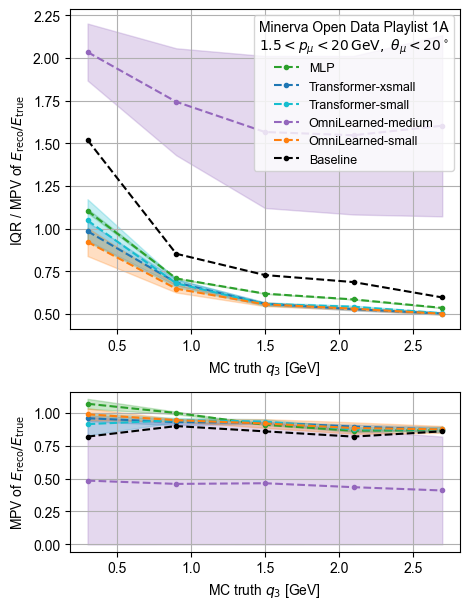

In [5]:
from eval_E_available_plots import plot_rms_iqr, plot_rms_iqr_with_uncertainty


fig_i = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full_no_rw,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    q3_bins=[0, 0.6, 1.2, 1.8, 2.4, 3.0, 100],
    show_q3_histograms=True,
    return_hist_fig=False,
    suppress_errors=SUPPRESS_ERRORS,
    use_cc_selection=1,
    colors=clrs_dict_full,
    text = (
        "Minerva Open Data Playlist 1A\n"
        r"$1.5 < p_\mu < 20\,\mathrm{GeV},\ \theta_\mu < 20^\circ$"
    )
)
fig_i.savefig(OUT_DIR / "q3_vs_iqr_rms_full_muon_selection_only.pdf", bbox_inches="tight")
#if fig_i_hist is not None:
#    fig_i_hist.savefig(OUT_DIR / "q3_vs_ratio_hist_full_1A.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_muon_selection_only.pdf")


Skipping Run_1703_OLM_FB_regression_-1_seed51_20260406_014743 on playlist 1B (no eval results found)
Skipping Run_1703_OLM_FB_regression_-1_seed52_20260406_130801 on playlist 1B (no eval results found)


Skipping Run_1703_OLM_FB_regression_-1_seed53_20260406_132149 on playlist 1B (no eval results found)


keys:  dict_keys(['1A', '1B'])


  baseline: RMS = [3.1519380126743584, 2.7268656891509586, 2.2263049920971496, 1.7388589291621968, 1.518727475622688], IQR = [1.487217046720863, 1.0462488814613664, 0.7105999848299569, 0.5819593962860639, 0.5260957263875167], MPV = [1.1, 0.86, 0.86, 0.86, 0.8200000000000001]
E_pred_dict keys for '1B': {'Log1p': ['MLP§0', 'MLP§1', 'MLP§2', 'MLP§3', 'Transformer-xsmall§0', 'Transformer-xsmall§1', 'Transformer-xsmall§2', 'Transformer-xsmall§3', 'Transformer-xsmall§4', 'Transformer-xsmall§5', 'Transformer-small§0', 'Transformer-small§1', 'Transformer-small§2', 'Transformer-small§3', 'OmniLearned-medium§2', 'OmniLearned-small§0', 'OmniLearned-small§1', 'OmniLearned-small§2', 'OmniLearned-small§3']}


  MLP (Log1p):
    RMS = [2.9516122341156006, 2.377939820289612, 1.674644261598587, 1.2422873079776764, 1.127179890871048]
    IQR = [1.341208428144455, 0.8665638118982315, 0.610544890165329, 0.5016162097454071, 0.450955867767334]
    MPV = [1.0299999713897705, 1.0299999713897705, 0.9950000047683716, 0.9099999666213989, 0.8899999856948853]


  Transformer-xsmall (Log1p):
    RMS = [2.436999519666036, 2.00841216246287, 1.4650998711585999, 1.118495225906372, 1.0683970252672832]
    IQR = [0.997779776652654, 0.7233193318049113, 0.5479109485944113, 0.4594634970029195, 0.42225581407546997]
    MPV = [0.9366666674613953, 0.9566666682561239, 0.9466666579246521, 0.9199999868869781, 0.9033333162466685]


  Transformer-small (Log1p):
    RMS = [2.4766674041748047, 2.014535963535309, 1.4615512788295746, 1.1178579926490784, 1.0695532262325287]
    IQR = [1.0300145149230957, 0.7385140061378479, 0.5540526956319809, 0.4620307385921478, 0.42252473533153534]
    MPV = [0.9500000178813934, 0.9749999940395355, 0.9699999988079071, 0.9049999862909317, 0.8849999904632568]
  OmniLearned-medium (Log1p):
    RMS = [1.1096445530653, 1.4301747097916833, 0.9149414852261544, 1.553606255132466, 0.9277808129787445]
    IQR = [0.6936971545219421, 0.658068835735321, 0.8610321506857872, 0.7920428775250912, 0.7668068110942841]
    MPV = [0.22749999165534973, 0.2224999964237213, 0.22749999165534973, 0.2224999964237213, 0.20749999582767487]


  OmniLearned-small (Log1p):
    RMS = [2.324075222015381, 1.9183676540851593, 1.4015892446041107, 1.0897832214832306, 1.0555512011051178]
    IQR = [0.9056077897548676, 0.662069171667099, 0.5119025856256485, 0.44690781831741333, 0.41561610996723175]
    MPV = [0.9699999988079071, 0.9650000184774399, 0.9600000083446503, 0.9099999815225601, 0.8799999803304672]


Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval_1/q3_vs_iqr_rms_full_1B.pdf


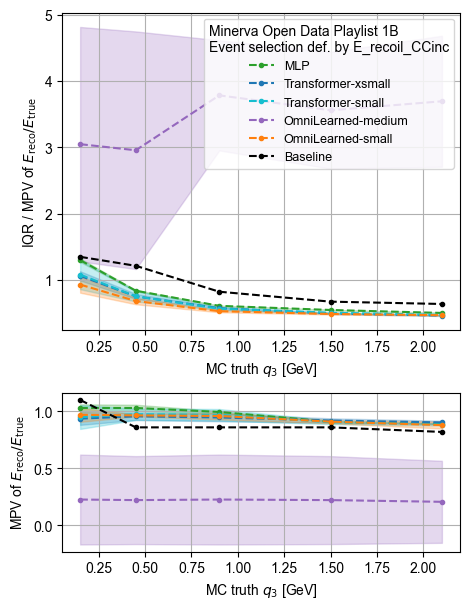

In [6]:
from eval_E_available_plots import plot_rms_iqr, plot_rms_iqr_with_uncertainty

fig_i = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full_no_rw,
    playlists=["1B"],
    dataset_to_plot="1B",
    baseline_run=baseline_run,
    show_q3_histograms=True,   # must be True to produce histograms (param is ignored, but for clarity)
    return_hist_fig=True,
    suppress_errors=SUPPRESS_ERRORS,
    colors=clrs_dict_full,
    text="Minerva Open Data Playlist 1B\nEvent selection def. by E_recoil_CCinc",
)
# The returned `values` dict contains the histograms used for IQR calculation:
#histograms = values.get("histograms", None)
# Now `histograms` will be a dict (if it is provided by the plotting function)
fig_i.savefig(OUT_DIR / "q3_vs_iqr_rms_full_1B.pdf", bbox_inches="tight")
#if fig_i_hist is not None:
#    fig_i_hist.savefig(OUT_DIR / "q3_vs_ratio_hist_full_1B.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_1B.pdf")

Skipping Run_1703_OLM_FB_regression_-1_seed52_20260406_130801 on playlist 1A (no eval results found)
Skipping Run_1703_OLM_FB_regression_-1_seed53_20260406_132149 on playlist 1A (no eval results found)


keys:  dict_keys(['1A', '1B'])



--- MLP (Log1p) [MLP§0] ---
  i        E_true        E_pred   pred/true
  0       2.70501       1.74862    0.646439
  1       0.15991       0.17941     1.12194
  2       4.53314       3.91564    0.863782
  3       1.19247      0.875572    0.734249
  4      0.142063      0.204068     1.43646
  5      0.169335      0.610428     3.60486
  6      0.598372      0.603883     1.00921
  7      0.398584       0.56558     1.41897
  8       1.04822      0.684365    0.652886
  9       2.20974       1.55335    0.702955

--- Transformer-xsmall (Log1p) [Transformer-xsmall§0] ---
  i        E_true        E_pred   pred/true
  0     0.0814167     0.0928144     1.13999
  1      0.341109      0.224103    0.656984
  2       0.85035      0.848024    0.997264
  3      0.665606      0.714688     1.07374
  4      0.822509        1.0936     1.32959
  5      0.560397       1.22108     2.17895
  6      0.510933      0.458068    0.896533
  7      0.896517       0.69154    0.771363
  8     0.0819253      0.109659 

Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval_1/debug_E_pred_vs_true_examples_1A.pdf


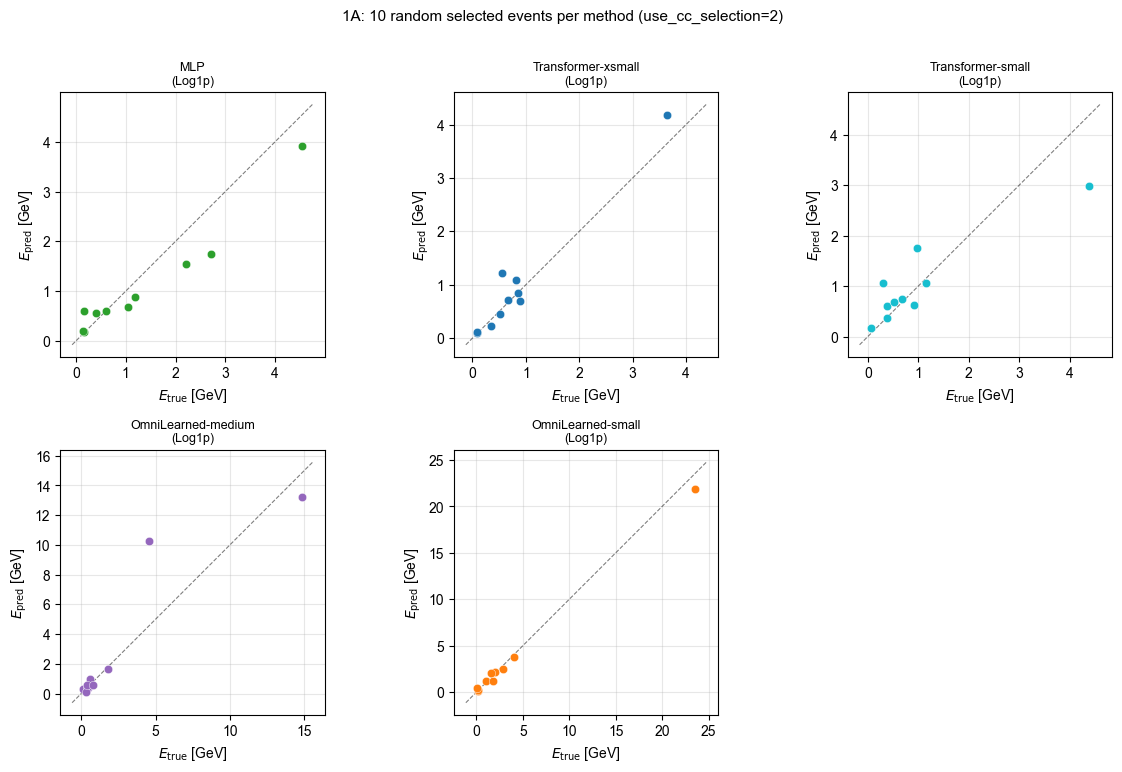

In [7]:
# Debug: a few E_true vs E_pred points per method (same selection as q3 plot above)
from eval_E_available_plots import plot_example_E_pred_true

fig_dbg = plot_example_E_pred_true(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full_no_rw,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    use_cc_selection=2,
    n_examples=10,
    seed=42,
    suppress_errors=SUPPRESS_ERRORS,
    colors=clrs_dict_full,
)
fig_dbg.savefig(OUT_DIR / "debug_E_pred_vs_true_examples_1A.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "debug_E_pred_vs_true_examples_1A.pdf")


Skipping Run_1703_OLM_FB_regression_-1_seed52_20260406_130801 on playlist 1A (no eval results found)
Skipping Run_1703_OLM_FB_regression_-1_seed53_20260406_132149 on playlist 1A (no eval results found)


keys:  dict_keys(['1A', '1B'])


  baseline: RMS = [3.148372598935032, 2.7791810405009967, 2.2176398351942384, 1.758116717480389, 1.504561280576312], IQR = [1.571619917564179, 1.0746723295343061, 0.7115179810480453, 0.5896458729592533, 0.5301364134724922], MPV = [1.18, 1.1400000000000001, 0.9, 0.86, 0.86]
E_pred_dict keys for '1A': {'Log1p': ['MLP§0', 'MLP§1', 'MLP§2', 'MLP§3', 'Transformer-xsmall§0', 'Transformer-xsmall§1', 'Transformer-xsmall§2', 'Transformer-xsmall§3', 'Transformer-xsmall§4', 'Transformer-xsmall§5', 'Transformer-small§0', 'Transformer-small§1', 'Transformer-small§2', 'Transformer-small§3', 'OmniLearned-medium§0', 'OmniLearned-medium§2', 'OmniLearned-small§0', 'OmniLearned-small§1', 'OmniLearned-small§2', 'OmniLearned-small§3']}
  MLP (Log1p):
    RMS = [3.0120474696159363, 2.368622839450836, 1.6729150712490082, 1.2688360810279846, 1.1612243056297302]
    IQR = [1.4406396746635437, 0.8917628973722458, 0.6122481822967529, 0.5027910321950912, 0.45515887439250946]
    MPV = [1.0850000083446503, 1.05499

  Transformer-xsmall (Log1p):
    RMS = [2.4949082136154175, 2.0009939670562744, 1.4580405155817668, 1.134791413942973, 1.1055286129315693]
    IQR = [1.0363753537336986, 0.7391322354475657, 0.5490889052549998, 0.46021680037180585, 0.4218603273232778]
    MPV = [0.9199999968210856, 0.9633333285649618, 0.9633333285649618, 0.9333333273728689, 0.8966666460037231]
  Transformer-small (Log1p):
    RMS = [2.463185489177704, 2.0036636292934418, 1.4700565040111542, 1.1303295493125916, 1.106362909078598]
    IQR = [1.0791624188423157, 0.754939392209053, 0.5543249547481537, 0.4630279392004013, 0.42227810621261597]
    MPV = [0.9099999815225601, 0.9799999743700027, 0.9600000083446503, 0.9399999976158142, 0.885000005364418]
  OmniLearned-medium (Log1p):
    RMS = [1.743593081831932, 1.777087241411209, 1.215173453092575, 1.629284608364105, 0.9987727776169777]
    IQR = [0.987184651196003, 0.8779598101973534, 0.7643675357103348, 0.7046999633312225, 0.6556449010968208]
    MPV = [0.48499999940395355,

  OmniLearned-small (Log1p):
    RMS = [2.2447698414325714, 1.8925612270832062, 1.4133227467536926, 1.1179623007774353, 1.1017500758171082]
    IQR = [0.9439091980457306, 0.6711517721414566, 0.5118752866983414, 0.4471462666988373, 0.4164040982723236]
    MPV = [0.9799999892711639, 0.9799999892711639, 0.939999982714653, 0.9199999868869781, 0.9249999970197678]


...

  MLP (Log1p):
    RMS = [2.9516122341156006, 2.377939820289612, 1.674644261598587, 1.2422873079776764, 1.127179890871048]
    IQR = [1.341208428144455, 0.8665638118982315, 0.610544890165329, 0.5016162097454071, 0.450955867767334]
    MPV = [1.0299999713897705, 1.0299999713897705, 0.9950000047683716, 0.9099999666213989, 0.8899999856948853]


  Transformer-xsmall (Log1p):
    RMS = [2.436999519666036, 2.00841216246287, 1.4650998711585999, 1.118495225906372, 1.0683970252672832]
    IQR = [0.997779776652654, 0.7233193318049113, 0.5479109485944113, 0.4594634970029195, 0.42225581407546997]
    MPV = [0.9366666674613953, 0.9566666682561239, 0.9466666579246521, 0.9199999868869781, 0.9033333162466685]


  Transformer-small (Log1p):
    RMS = [2.4766674041748047, 2.014535963535309, 1.4615512788295746, 1.1178579926490784, 1.0695532262325287]
    IQR = [1.0300145149230957, 0.7385140061378479, 0.5540526956319809, 0.4620307385921478, 0.42252473533153534]
    MPV = [0.9500000178813934, 0.9749999940395355, 0.9699999988079071, 0.9049999862909317, 0.8849999904632568]
  OmniLearned-medium (Log1p):
    RMS = [1.1096445530653, 1.4301747097916833, 0.9149414852261544, 1.553606255132466, 0.9277808129787445]
    IQR = [0.6936971545219421, 0.658068835735321, 0.8610321506857872, 0.7920428775250912, 0.7668068110942841]
    MPV = [0.22749999165534973, 0.2224999964237213, 0.22749999165534973, 0.2224999964237213, 0.20749999582767487]


  OmniLearned-small (Log1p):
    RMS = [2.324075222015381, 1.9183676540851593, 1.4015892446041107, 1.0897832214832306, 1.0555512011051178]
    IQR = [0.9056077897548676, 0.662069171667099, 0.5119025856256485, 0.44690781831741333, 0.41561610996723175]
    MPV = [0.9699999988079071, 0.9650000184774399, 0.9600000083446503, 0.9099999815225601, 0.8799999803304672]


Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval_1/q3_vs_iqr_rms_full_1A_1B.pdf


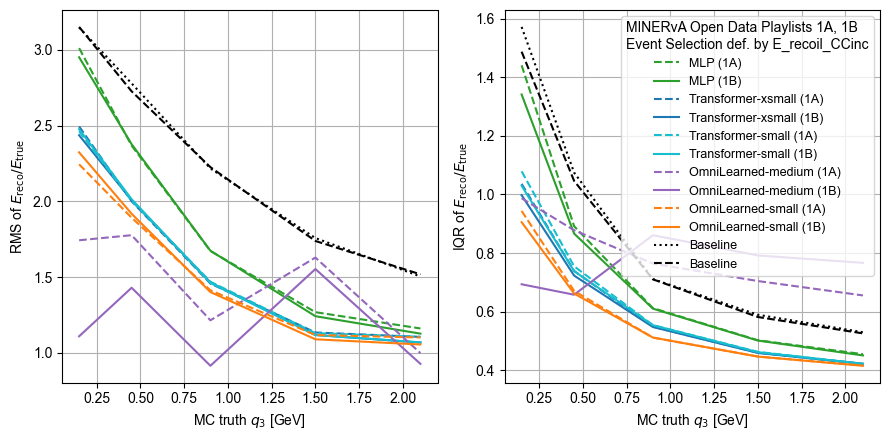

In [8]:
from eval_E_available_plots import plot_rms_iqr_with_uncertainty

# 1A: get per-config means (and close the internal figure)
fig_1A, vals_1A = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full_no_rw,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    suppress_errors=SUPPRESS_ERRORS,
    return_values=True,
)
plt.close(fig_1A)

# 1B: same
fig_1B, vals_1B = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full_no_rw,
    playlists=["1B"],
    dataset_to_plot="1B",
    baseline_run=baseline_run,
    suppress_errors=SUPPRESS_ERRORS,
    return_values=True,
)
plt.close(fig_1B)

q3 = vals_1A["q3_bin_mids"]

fig_both, ax = plt.subplots(1, 2, figsize=(9, 4.5))

# Same colors as other q3 plots (clrs_dict_full)
for loss in vals_1A:
    if loss in ("q3_bin_mids", "baseline"):
        continue
    for cfg_label, vA in vals_1A[loss].items():
        method = cfg_label.split()[0]
        color = clrs_dict_full.get(method, "tab:gray")

        # 1A mean only
        ax[0].plot(
            q3, vA["rms_mean"], "--", color=color,
            label=f"{method} (1A)"
        )
        ax[1].plot(
            q3, vA["iqr_mean"], "--", color=color,
            label=f"{method} (1A)"
        )

        # 1B mean only, if present
        vB = vals_1B.get(loss, {}).get(cfg_label)
        if vB is not None:
            ax[0].plot(
                q3, vB["rms_mean"], "-",
                color=color, label=f"{method} (1B)"
            )
            ax[1].plot(
                q3, vB["iqr_mean"], "-",
                color=color, label=f"{method} (1B)"
            )

# Optional: baseline line if present
if "baseline" in vals_1A:
    bl = vals_1A["baseline"]
    ax[0].plot(q3, bl["rms"], "k:", label="Baseline")
    ax[1].plot(q3, bl["iqr"], "k:", label="Baseline")
if "baseline" in vals_1B:
    bl = vals_1B["baseline"]
    ax[0].plot(q3, bl["rms"], "k--", label="Baseline")
    ax[1].plot(q3, bl["iqr"], "k--", label="Baseline")

ax[0].set(
    xlabel="MC truth $q_3$ [GeV]",
    ylabel="RMS of $E_{\\mathrm{reco}}/E_{\\mathrm{true}}$",
)
ax[1].set(
    xlabel="MC truth $q_3$ [GeV]",
    ylabel="IQR of $E_{\\mathrm{reco}}/E_{\\mathrm{true}}$",
)

selection_text = (
    "MINERvA Open Data Playlists 1A, 1B\n"
    r"Event Selection def. by E_recoil_CCinc"
)

# Rebuild legends with a shared title describing the selection
#leg0 = ax[0].legend(title=selection_text, fontsize=9, loc="upper right")
#leg0.set_title(selection_text)

leg1 = ax[1].legend(title=selection_text, fontsize=9, loc="upper right")
leg1.set_title(selection_text)

ax[0].grid(True)
ax[1].grid(True)

fig_both.tight_layout()
fig_both.savefig(OUT_DIR / "q3_vs_iqr_rms_full_1A_1B.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_1A_1B.pdf")

## (II) Residuals by energy – full training dataset

keys:  dict_keys(['1A', '1B'])


Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval_1/residuals_by_energy_full.pdf


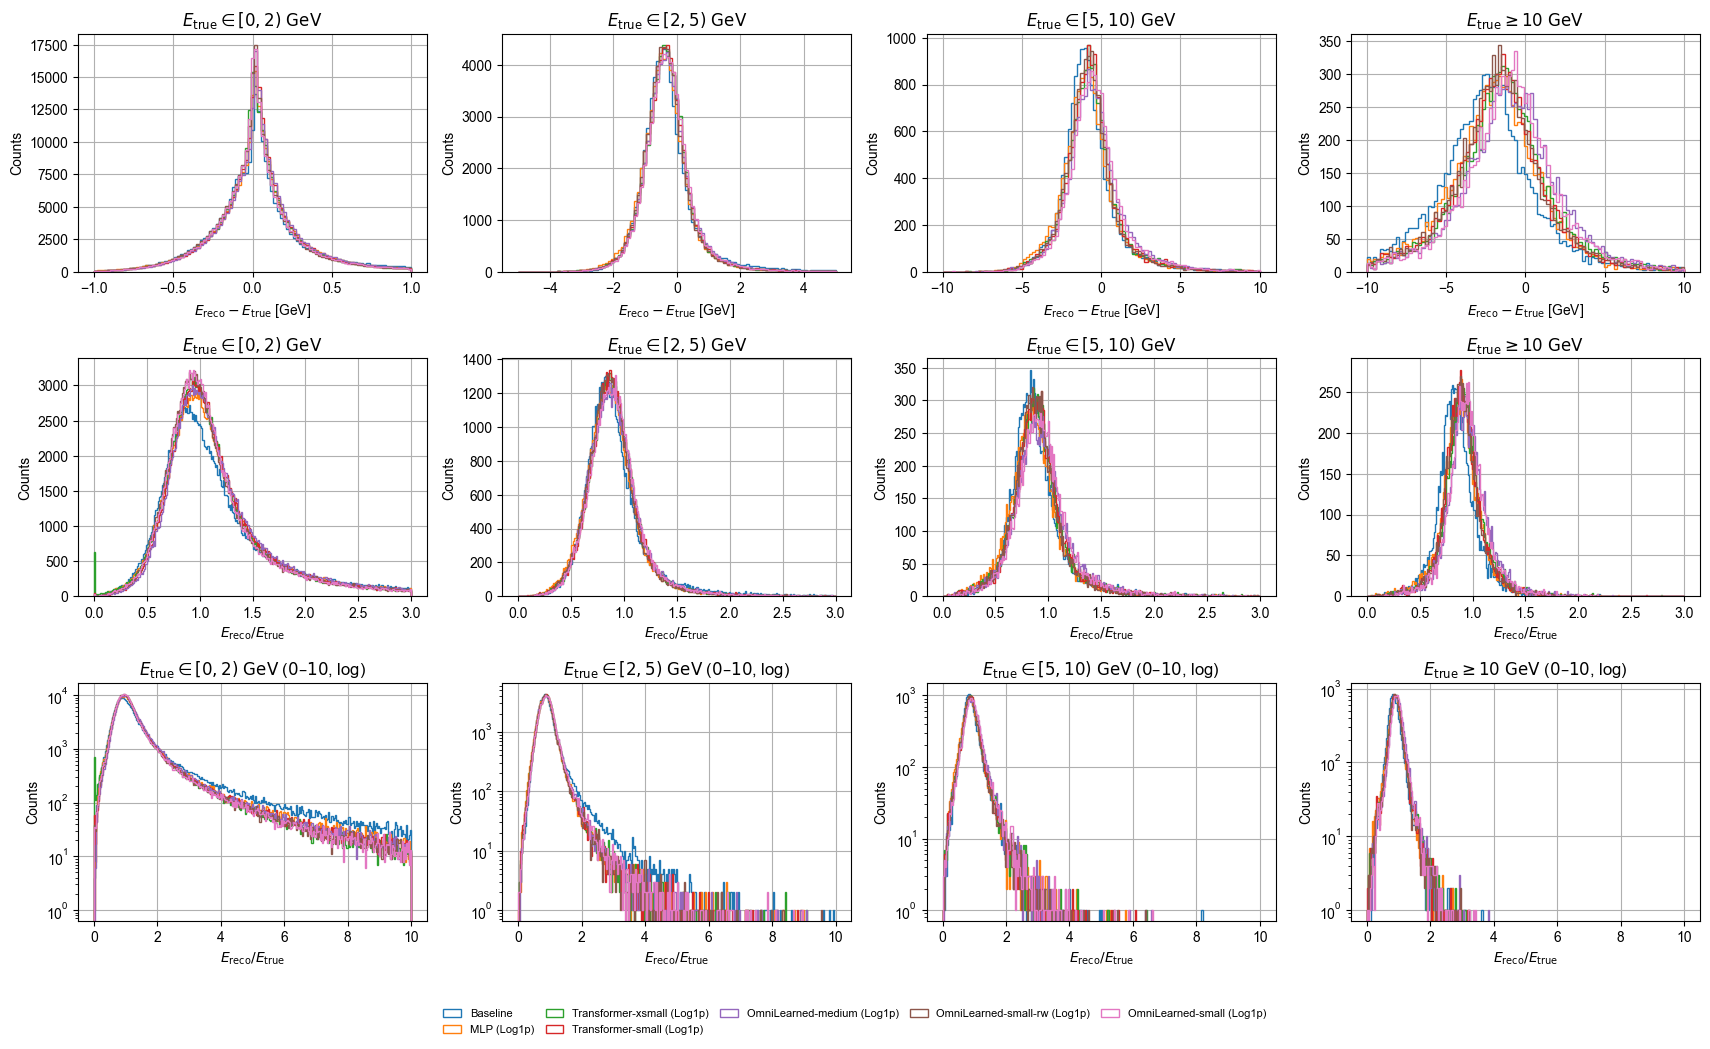

In [9]:
from eval_E_available_plots import plot_residuals_by_energy, plot_residuals_by_q3
# Existing: training_names_full = {"Log1p": {...}} built above

training_names_full_first_only: dict[str, dict[str, str]] = {}
for loss, models in training_names_full.items():
    training_names_full_first_only[loss] = {}
    for model, runs in models.items():
        if isinstance(runs, list):
            if not runs:
                continue
            training_names_full_first_only[loss][model] = runs[0]
        else:
            training_names_full_first_only[loss][model] = runs

fig_ii = plot_residuals_by_energy(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full_first_only,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    suppress_errors=SUPPRESS_ERRORS,
)
fig_ii.savefig(OUT_DIR / "residuals_by_energy_full.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "residuals_by_energy_full.pdf")



keys:  dict_keys(['1A', '1B'])


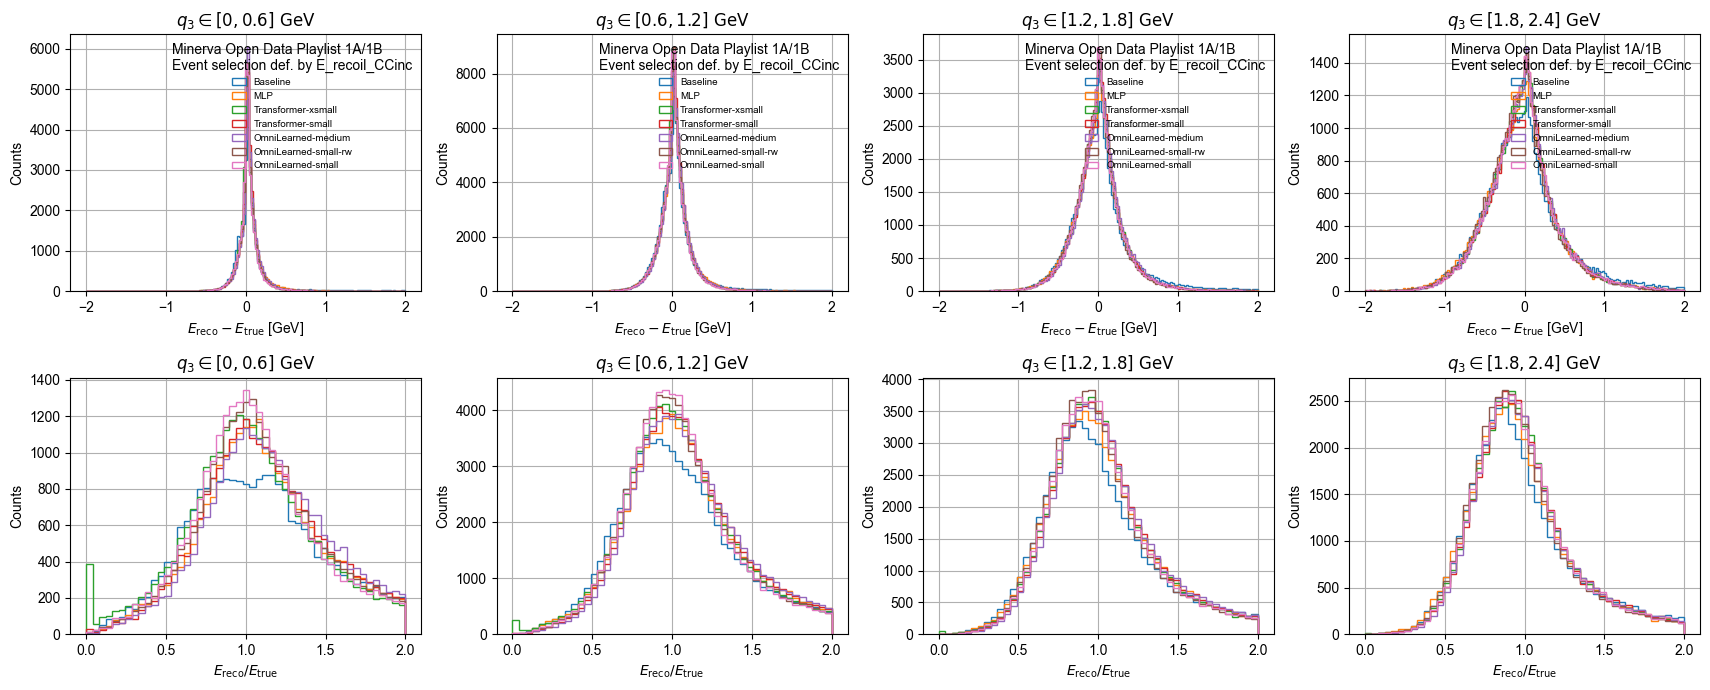

In [10]:
fig_ii_q3 = plot_residuals_by_q3(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full_first_only,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    q3_bins=[0, 0.6, 1.2, 1.8, 2.4],
    suppress_errors=SUPPRESS_ERRORS,
)
fig_ii_q3.savefig(OUT_DIR / "residuals_by_q3_select_events_by_E_recoil_CCinc.pdf", bbox_inches="tight")

keys:  dict_keys(['1A', '1B'])


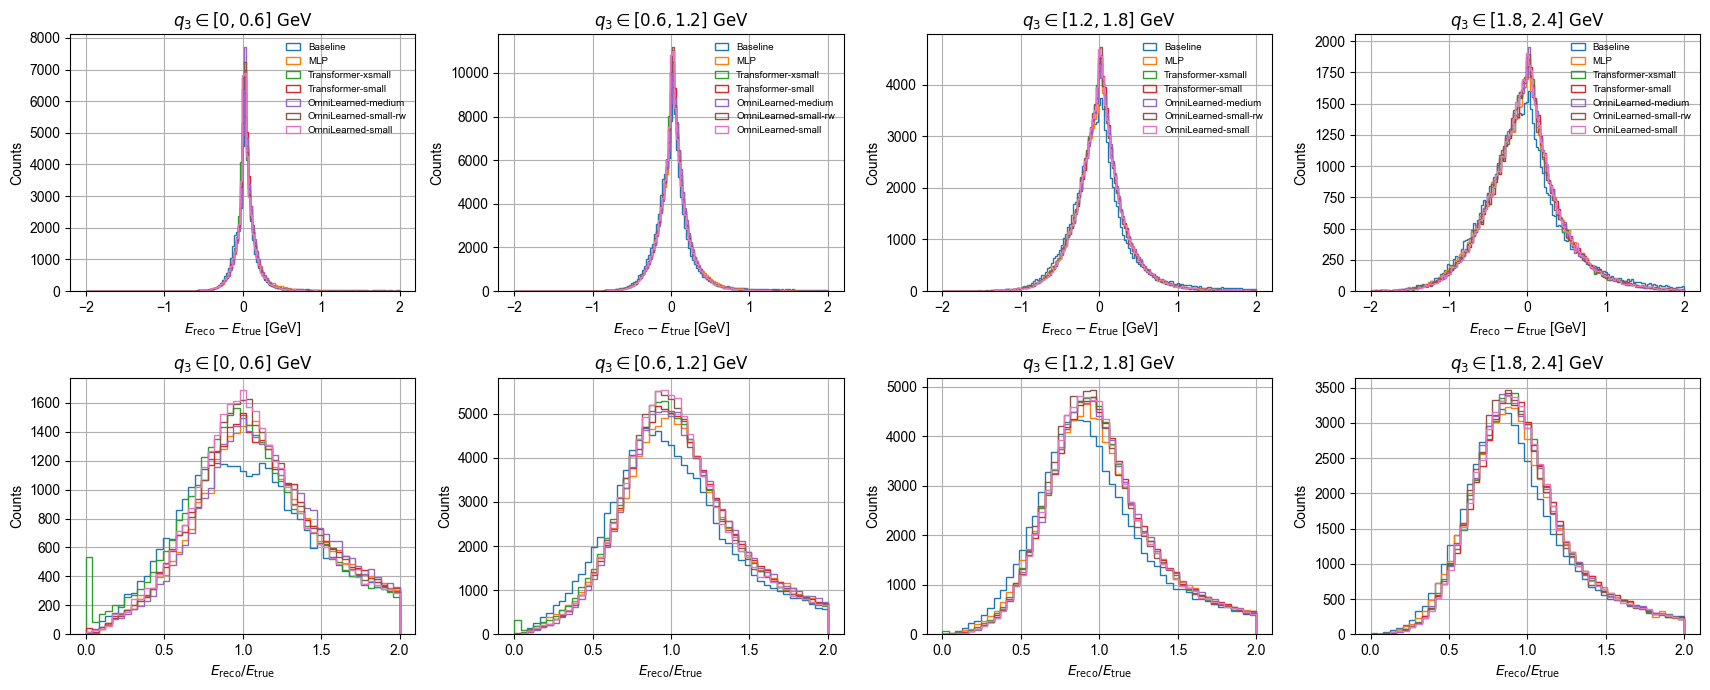

In [11]:
fig_ii_q3 = plot_residuals_by_q3(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full_first_only,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    q3_bins=[0, 0.6, 1.2, 1.8, 2.4],
    suppress_errors=SUPPRESS_ERRORS,
    use_cc_selection=1,
)
fig_ii_q3.savefig(OUT_DIR / "residuals_by_q3_select_events_by_muons.pdf", bbox_inches="tight")

## (III) IQR vs number of training samples – bin 2 (all models)

Skipping Run_1703_OLM_FB_regression_-1_seed52_20260406_130801 on playlist 1A (no eval results found)
Skipping Run_1703_OLM_FB_regression_-1_seed53_20260406_132149 on playlist 1A (no eval results found)


keys:  dict_keys(['1A', '1B'])


  baseline: RMS = [3.148372598935032, 2.7791810405009967, 2.2176398351942384, 1.758116717480389, 1.504561280576312], IQR = [1.571619917564179, 1.0746723295343061, 0.7115179810480453, 0.5896458729592533, 0.5301364134724922], MPV = [1.18, 1.1400000000000001, 0.9, 0.86, 0.86]
E_pred_dict keys for '1A': {'Log1p': ['MLP 6M§0', 'MLP 6M§1', 'MLP 6M§2', 'MLP 6M§3', 'Transformer-xsmall 6M§0', 'Transformer-xsmall 6M§1', 'Transformer-xsmall 6M§2', 'Transformer-xsmall 6M§3', 'Transformer-xsmall 6M§4', 'Transformer-xsmall 6M§5', 'Transformer-small 6M§0', 'Transformer-small 6M§1', 'Transformer-small 6M§2', 'Transformer-small 6M§3', 'OmniLearned-medium 6M§0', 'OmniLearned-medium 6M§2', 'OmniLearned-small-rw 6M§0', 'OmniLearned-small-rw 6M§1', 'OmniLearned-small-rw 6M§2', 'OmniLearned-small 6M§0', 'OmniLearned-small 6M§1', 'OmniLearned-small 6M§2', 'OmniLearned-small 6M§3']}
  MLP 6M (Log1p):
    RMS = [3.0120474696159363, 2.368622839450836, 1.6729150712490082, 1.2688360810279846, 1.1612243056297302]


  Transformer-xsmall 6M (Log1p):
    RMS = [2.4949082136154175, 2.0009939670562744, 1.4580405155817668, 1.134791413942973, 1.1055286129315693]
    IQR = [1.0363753537336986, 0.7391322354475657, 0.5490889052549998, 0.46021680037180585, 0.4218603273232778]
    MPV = [0.9199999968210856, 0.9633333285649618, 0.9633333285649618, 0.9333333273728689, 0.8966666460037231]
  Transformer-small 6M (Log1p):
    RMS = [2.463185489177704, 2.0036636292934418, 1.4700565040111542, 1.1303295493125916, 1.106362909078598]
    IQR = [1.0791624188423157, 0.754939392209053, 0.5543249547481537, 0.4630279392004013, 0.42227810621261597]
    MPV = [0.9099999815225601, 0.9799999743700027, 0.9600000083446503, 0.9399999976158142, 0.885000005364418]
  OmniLearned-medium 6M (Log1p):
    RMS = [1.743593081831932, 1.777087241411209, 1.215173453092575, 1.629284608364105, 0.9987727776169777]
    IQR = [0.987184651196003, 0.8779598101973534, 0.7643675357103348, 0.7046999633312225, 0.6556449010968208]
    MPV = [0.484999999

  OmniLearned-small-rw 6M (Log1p):
    RMS = [2.3324315547943115, 1.9128516515096028, 1.422574559847514, 1.115427851676941, 1.094666322072347]
    IQR = [0.9856808582941691, 0.6946246027946472, 0.5201878150304159, 0.44830501079559326, 0.4162893295288086]
    MPV = [0.9166666666666666, 1.0233333110809326, 0.9433333476384481, 0.9433333277702332, 0.8633333444595337]
  OmniLearned-small 6M (Log1p):
    RMS = [2.2447698414325714, 1.8925612270832062, 1.4133227467536926, 1.1179623007774353, 1.1017500758171082]
    IQR = [0.9439091980457306, 0.6711517721414566, 0.5118752866983414, 0.4471462666988373, 0.4164040982723236]
    MPV = [0.9799999892711639, 0.9799999892711639, 0.939999982714653, 0.9199999868869781, 0.9249999970197678]


Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval_1/iqr_vs_n_samples_bin2.pdf


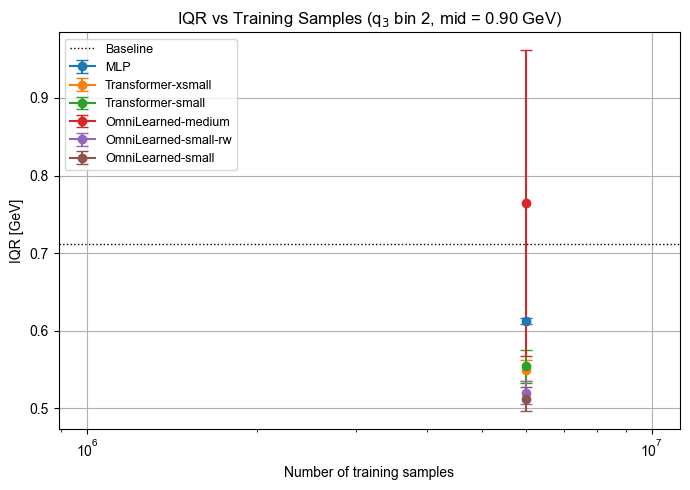

In [12]:
import re
import numpy as np
import matplotlib.pyplot as plt
from eval_E_available_plots import plot_rms_iqr_with_uncertainty

# Build grouped training names for this plot on the fly

def _cap_to_label(cap):
    if cap == -1:
        return "6M"
    if cap >= 1_000_000:
        return f"{cap // 1_000_000}M"
    return f"{cap // 1000}k"

training_names_grouped = {"Log1p": {}}
for model, caps in runs_by_model_cap.items():
    for cap, run_list in sorted(caps.items(), key=lambda x: (x[0] == -1, -x[0] if x[0] > 0 else 0)):
        if not run_list:
            continue
        label = f"{model} {_cap_to_label(cap)}"
        training_names_grouped["Log1p"][label] = run_list

if not training_names_grouped["Log1p"]:
    raise SystemExit("No runs for scaling plot. Check WANDB_TAG.")

_, values = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_grouped,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    return_values=True,
    suppress_errors=SUPPRESS_ERRORS,
)
plt.close()

Q3_BIN_IDX = 2

def _n_samples(label):
    m = re.search(r"(\d+(?:\.\d+)?)\s*([kKmM])\b", label)
    if m:
        return float(m.group(1)) * (1e6 if m.group(2).upper() == "M" else 1e3)
    return 0.0

def _method(label):
    return re.sub(r"\s+\d+(?:\.\d+)?[kKmM]$", "", label)

methods = {}
for loss in values:
    if loss in ("q3_bin_mids", "baseline"):
        continue
    for cfg, v in values[loss].items():
        methods.setdefault(_method(cfg), []).append(
            (_n_samples(cfg), v["iqr_mean"][Q3_BIN_IDX], v["iqr_std"][Q3_BIN_IDX])
        )

for m in methods:
    methods[m].sort()

fig_iii, ax = plt.subplots(figsize=(7, 5))
for method, pts in methods.items():
    xs, ys, yerrs = zip(*pts)
    ax.errorbar(xs, ys, yerr=yerrs, marker="o", capsize=4, label=method)

if "baseline" in values:
    ax.axhline(values["baseline"]["iqr"][Q3_BIN_IDX],
               color="black", linestyle=":", lw=1, label="Baseline")

ax.set_xscale("log")
ax.set_xlabel("Number of training samples")
ax.set_ylabel("IQR [GeV]")
q3_mid = values["q3_bin_mids"][Q3_BIN_IDX]
ax.set_title(f"IQR vs Training Samples (q$_3$ bin {Q3_BIN_IDX}, mid = {q3_mid:.2f} GeV)")
ax.legend(fontsize=9)
ax.grid(True)
fig_iii.tight_layout()
fig_iii.savefig(OUT_DIR / "iqr_vs_n_samples_bin2.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "iqr_vs_n_samples_bin2.pdf")

In [13]:
# For each model, get the values of the field "eval_loss". This is validation loss logged to wandb each 1000 steps
# Use this and make a plot of log flops vs validation loss for each model.

# Flops for BS 2048

flops_per_step = {
    "Transformer-xsmall": 358.5 * 1e9,  # Transformer1 / Transformer1NR (same ViT depth)
    "OmniLearned-small": 1769 * 1e9,
    "MLP": 2.6 * 1e9,
    "OmniLearned-medium": 8035 * 1e9,
    "OmniLearned-small-rw": 1769 * 1e9,
    "Transformer2": 6236 * 1e9,
    "Transformer-small": 1263 * 1e9
}


def get_validation_loss_history(run_name, project="minerva-models", with_steps=False):
    """Return array of all logged eval_loss values for a run (from wandb history).
    If with_steps=True, return (steps, losses) for x-axis (e.g. cumulative flops)."""
    import os
    import numpy as np
    import wandb
    api = wandb.Api(timeout=60)
    entity = os.environ.get("WANDB_ENTITY") or getattr(api, "default_entity", None)
    if not entity:
        raise RuntimeError("WANDB_ENTITY not set and wandb default_entity unknown. Run wandb login or set WANDB_ENTITY.")
    path = f"{entity}/{project}"
    runs = api.runs(path, filters={"displayName": run_name})
    run = next(iter(runs), None)
    if run is None:
        raise ValueError(f"Wandb run not found: {run_name!r} in {path}")
    hist = run.history()
    if "eval_loss" not in hist.columns:
        return (np.array([]), np.array([])) if with_steps else np.array([])
    mask = hist["eval_loss"].notna()
    steps = np.asarray(hist["_step"], dtype=float)[mask]
    losses = np.asarray(hist["eval_loss"].dropna(), dtype=float)
    # Keep only every 1000th step (1000, 2000, 3000, ...) as data points
    step_int = np.round(steps).astype(int)
    keep = (step_int >= 1000) & (step_int % 1000 == 0)
    steps, losses = steps[keep], losses[keep]
    # Sort by step and take first occurrence per step (in case of duplicates)
    order = np.argsort(steps)
    steps, losses = steps[order], losses[order]
    _, idx = np.unique(np.round(steps).astype(int), return_index=True)
    steps = steps[np.sort(idx)]
    losses = losses[np.sort(idx)]
    if with_steps:
        return steps, losses
    return losses



wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=60 sec). Create a new API with an integer timeout larger than 60, e.g., `api = wandb.Api(timeout=70)` to increase the graphql timeout.


Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval_1/log_flops_vs_val_loss.pdf


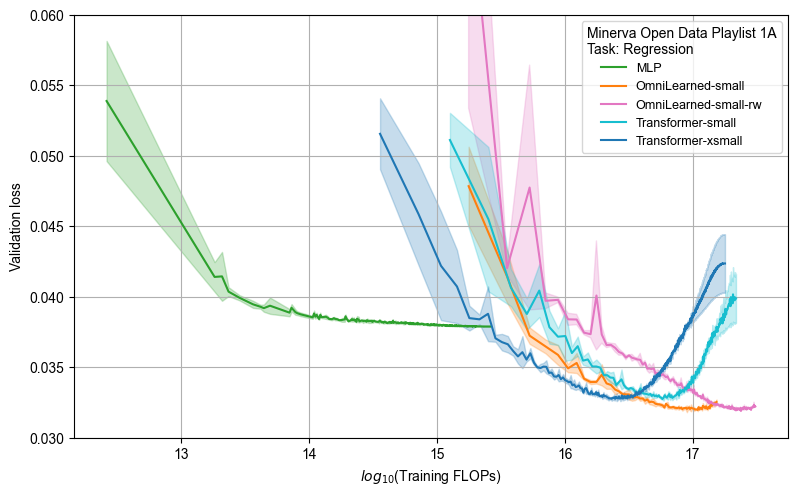

In [14]:
# Log flops vs validation loss: one curve per model; data points every 1000 steps; ±1 sigma band across runs (when available)
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt

loss_plot_legend_title = (
    "Minerva Open Data Playlist 1A\n"
    "Task: Regression"
)
# Runs per model for full dataset (cap=-1); use all seeds when available
runs_per_model = OrderedDict()
for model in sorted(flops_per_step):
    if model not in runs_by_model_cap or -1 not in runs_by_model_cap[model]:
        run_name = training_names_full["Log1p"].get(model)
        if run_name:
            runs_per_model[model] = [run_name]
        continue
    runs_per_model[model] = runs_by_model_cap[model][-1]

fig, ax = plt.subplots(figsize=(8, 5))
#colors = plt.cm.tab10(np.linspace(0, 1, len(runs_per_model)))
colors = {
    "Transformer-xsmall": "#1f77b4",
    "Transformer-small": "#17becf",
    "OmniLearned-small": "#ff7f0e",
    "MLP": "#2ca02c",
    "OmniLearned-medium": "#9467bd",
    "OmniLearned-small-rw": "#e377c2",
    "Transformer2": "#d62728",
}

for (model, run_names) in runs_per_model.items():
    if model == "OmniLearned-medium":
        continue
    color = colors[model]
    flops = flops_per_step[model]
    all_steps, all_losses = [], []
    for rn in run_names:
        st, lo = get_validation_loss_history(rn, with_steps=True)  # already every 1000 steps
        if len(st) > 0 and len(lo) > 0:
            all_steps.append(st)
            all_losses.append(lo)

    if not all_steps:
        continue

    # Full range: union of all steps across runs (no truncation to minimum)
    steps_grid = np.unique(np.concatenate(all_steps)).astype(float)
    if len(steps_grid) == 0:
        continue
    # Interpolate each run onto the common grid (extrapolates with edge values beyond run range)
    losses_aligned = np.array([
        np.interp(steps_grid, st, lo) for st, lo in zip(all_steps, all_losses)
    ])

    mean_loss = np.mean(losses_aligned, axis=0)
    # Std across runs only (when multiple runs); no band for single run
    sigma_loss = np.std(losses_aligned, axis=0) if losses_aligned.shape[0] > 1 else np.zeros_like(mean_loss)

    cum_flops = steps_grid * flops
    x = np.log10(cum_flops + 1)  # +1 to avoid log(0) at step 0
    #mask = x <= 16.5
    x_plot = x
    mean_loss_plot = mean_loss
    sigma_loss_plot = sigma_loss
    ax.plot(x_plot, mean_loss_plot, color=color, label=model)
    if losses_aligned.shape[0] > 1:
        ax.fill_between(x_plot, mean_loss_plot - sigma_loss_plot, mean_loss_plot + sigma_loss_plot, alpha=0.25, color=color)

ax.set_xlabel(f"$log_{{10}}$(Training FLOPs)")
ax.set_ylabel("Validation loss")
leg_flops = ax.legend(title=loss_plot_legend_title, fontsize=9, loc="upper right")
leg_flops.set_title(loss_plot_legend_title)
ax.grid(True)
fig.tight_layout()
ax.set_ylim(0.03, 0.06)
fig.savefig(OUT_DIR / "log_flops_vs_val_loss.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "log_flops_vs_val_loss.pdf")
plt.show()

Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval_1/log_steps_vs_val_loss.pdf


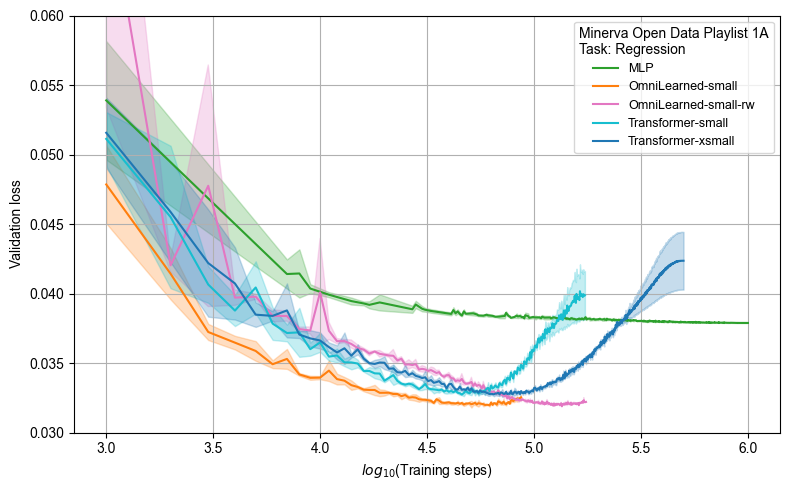

In [15]:
# Plot: Validation loss vs log10(training step), with custom cut for OLM models
loss_plot_legend_title = (
    "Minerva Open Data Playlist 1A\n"
    "Task: Regression"
)

fig2, ax2 = plt.subplots(figsize=(8, 5))

for model, run_names in runs_per_model.items():
    if model == "OmniLearned-medium":
        continue
    all_steps, all_losses = [], []
    color = colors[model]
    for rn in run_names:
        st, lo = get_validation_loss_history(rn, with_steps=True)
        if len(st) > 0 and len(lo) > 0:
            all_steps.append(st)
            all_losses.append(lo)

    if not all_steps:
        continue

    steps_grid = np.unique(np.concatenate(all_steps)).astype(float)
    if len(steps_grid) == 0:
        continue

    losses_aligned = np.array([
        np.interp(steps_grid, st, lo) for st, lo in zip(all_steps, all_losses)
    ])
    mean_loss = np.mean(losses_aligned, axis=0)
    sigma_loss = np.std(losses_aligned, axis=0) if losses_aligned.shape[0] > 1 else np.zeros_like(mean_loss)

    step_mask = np.full_like(steps_grid, True, dtype=bool)
    steps_plot = steps_grid[step_mask]
    mean_loss_plot = mean_loss[step_mask]
    sigma_loss_plot = sigma_loss[step_mask]

    log_steps_plot = np.log10(steps_plot + 1)
    ax2.plot(log_steps_plot, mean_loss_plot, color=color, label=model)
    if losses_aligned.shape[0] > 1:
        ax2.fill_between(log_steps_plot, mean_loss_plot - sigma_loss_plot, mean_loss_plot + sigma_loss_plot, alpha=0.25, color=color)

ax2.set_xlabel(f"$log_{{10}}$(Training steps)")
ax2.set_ylabel("Validation loss")
ax2.set_ylim(0.03, 0.06)
leg_steps = ax2.legend(title=loss_plot_legend_title, fontsize=9, loc="upper right")
leg_steps.set_title(loss_plot_legend_title)
ax2.grid(True)
fig2.tight_layout()
fig2.savefig(OUT_DIR / "log_steps_vs_val_loss.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "log_steps_vs_val_loss.pdf")
plt.show()
